In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pyarrow.parquet as pq


df = pd.read_parquet(
    "../../data/external/upgrade0.parquet"
)
import os
print(os.path.exists("../../data/external/upgrade0.parquet"))


GROUPS = {
    "Confort thermique": {
        "color": "#E85D24",
        "cols": [
            "out.electricity.heating.energy_consumption..kwh",
            "out.electricity.heating_fans_pumps.energy_consumption..kwh",
            "out.electricity.heating_hp_bkup.energy_consumption..kwh",
            "out.electricity.heating_hp_bkup_fa.energy_consumption..kwh",
            "out.electricity.cooling.energy_consumption..kwh",
            "out.electricity.cooling_fans_pumps.energy_consumption..kwh",
            "out.natural_gas.heating.energy_consumption..kwh",
            "out.fuel_oil.heating.energy_consumption..kwh",
            "out.propane.heating.energy_consumption..kwh",
        ],
    },
    "Eau chaude sanitaire": {
        "color": "#378ADD",
        "cols": [
            "out.electricity.hot_water.energy_consumption..kwh",
            "out.electricity.hot_water_solar_th.energy_consumption..kwh",
            "out.natural_gas.hot_water.energy_consumption..kwh",
            "out.fuel_oil.hot_water.energy_consumption..kwh",
            "out.propane.hot_water.energy_consumption..kwh",
        ],
    },
    "Hygiène & nettoyage": {
        "color": "#1D9E75",
        "cols": [
            "out.electricity.clothes_washer.energy_consumption..kwh",
            "out.electricity.clothes_dryer.energy_consumption..kwh",
            "out.natural_gas.clothes_dryer.energy_consumption..kwh",
            "out.propane.clothes_dryer.energy_consumption..kwh",
            "out.electricity.dishwasher.energy_consumption..kwh",
        ],
    },
    "Alimentation": {
        "color": "#BA7517",
        "cols": [
            "out.electricity.range_oven.energy_consumption..kwh",
            "out.natural_gas.range_oven.energy_consumption..kwh",
            "out.propane.range_oven.energy_consumption..kwh",
            "out.electricity.refrigerator.energy_consumption..kwh",
            "out.electricity.freezer.energy_consumption..kwh",
            "out.natural_gas.grill.energy_consumption..kwh",
        ],
    },
    "Divertissement & loisirs": {
        "color": "#7F77DD",
        "cols": [
            "out.electricity.television.energy_consumption..kwh",
            "out.electricity.plug_loads.energy_consumption..kwh",
            "out.electricity.ceiling_fan.energy_consumption..kwh",
            "out.electricity.pool_pump.energy_consumption..kwh",
            "out.electricity.pool_heater.energy_consumption..kwh",
            "out.natural_gas.pool_heater.energy_consumption..kwh",
            "out.electricity.permanent_spa_pump.energy_consumption..kwh",
            "out.electricity.permanent_spa_heat.energy_consumption..kwh",
            "out.natural_gas.permanent_spa_heat.energy_consumption..kwh",
        ],
    },
    "Éclairage & ambiance": {
        "color": "#F2A623",
        "cols": [
            "out.electricity.lighting_interior.energy_consumption..kwh",
            "out.electricity.lighting_exterior.energy_consumption..kwh",
            "out.electricity.lighting_garage.energy_consumption..kwh",
            "out.natural_gas.lighting.energy_consumption..kwh",
            "out.natural_gas.fireplace.energy_consumption..kwh",
        ],
    },
    "Mobilité (VE)": {
        "color": "#D4537E",
        "cols": [
            "out.electricity.ev_charging.energy_consumption..kwh",
        ],
    },
    "Infrastructure": {
        "color": "#888780",
        "cols": [
            "out.electricity.mech_vent.energy_consumption..kwh",
            "out.electricity.well_pump.energy_consumption..kwh",
        ],
    },
    "Production PV": {
        "color": "#639922",
        "cols": [
            "out.electricity.pv.energy_consumption..kwh",   # valeur négative
        ],
    },
}

TOTAL_COL = "out.site_energy.net.energy_consumption..kwh"
ELEC_NET  = "out.electricity.net.energy_consumption..kwh"
GAS_TOT   = "out.natural_gas.total.energy_consumption..kwh"
FUEL_TOT  = "out.fuel_oil.total.energy_consumption..kwh"
PROP_TOT  = "out.propane.total.energy_consumption..kwh"

#garder seulement les colonnes présentes dans df
def existing(cols):
    return [c for c in cols if c in df.columns]

# somme sur tous les ménages × weight
def weighted_sum(col):
    if col not in df.columns:
        return 0.0
    return (df[col] * df["weight"]).sum()

group_totals = {
    name: sum(weighted_sum(c) for c in info["cols"])
    for name, info in GROUPS.items()
}
group_colors = {name: info["color"] for name, info in GROUPS.items()}




True


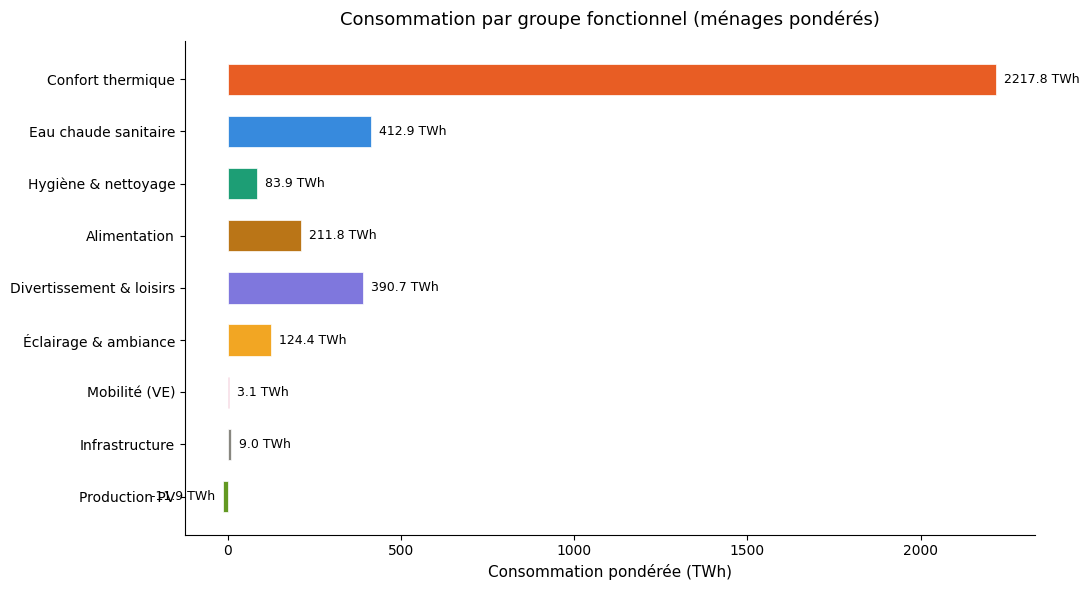

In [22]:
#consommation élémentaire par groupe

fig1, ax1 = plt.subplots(figsize=(11, 6))
names  = list(group_totals.keys())
values = [group_totals[n] / 1e9 for n in names]   # TWh
colors = [group_colors[n] for n in names]

bars = ax1.barh(names, values, color=colors, height=0.6, edgecolor="white", linewidth=0.5)
ax1.bar_label(bars, fmt="%.1f TWh", padding=6, fontsize=9)
ax1.set_xlabel("Consommation pondérée (TWh)", fontsize=11)
ax1.set_title("Consommation par groupe fonctionnel (ménages pondérés)", fontsize=13, pad=12)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
ax1.invert_yaxis()
ax1.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz1_barres_groupes.png", dpi=150)
plt.show()

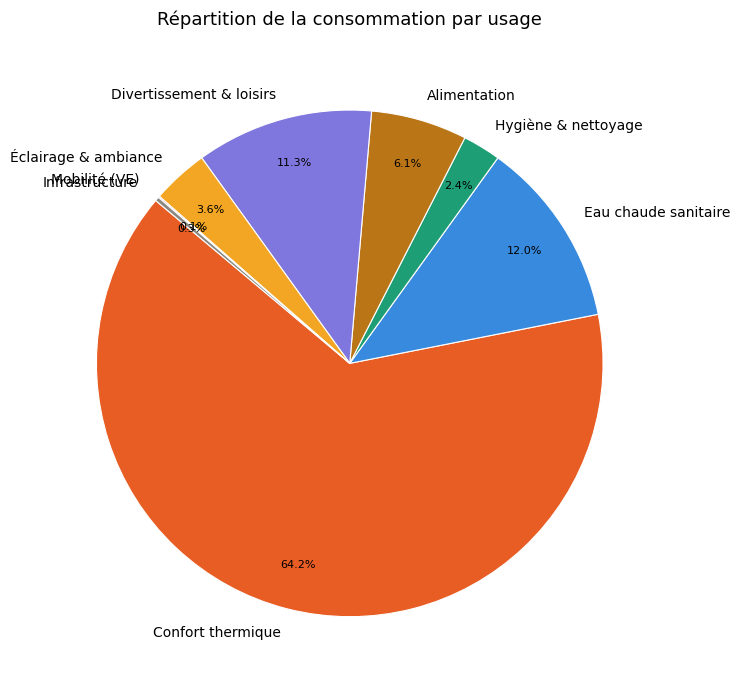

In [24]:
# Camembert : part de chaque groupe dans la consommation totale

fig2, ax2 = plt.subplots(figsize=(9, 7))
pos_names  = [n for n in names if group_totals[n] > 0]
pos_values = [group_totals[n] for n in pos_names]
pos_colors = [group_colors[n] for n in pos_names]

wedges, texts, autotexts = ax2.pie(
    pos_values,
    labels=pos_names,
    colors=pos_colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.82,
    wedgeprops={"linewidth": 0.8, "edgecolor": "white"},
)
for t in autotexts:
    t.set_fontsize(8)
ax2.set_title("Répartition de la consommation par usage", fontsize=13, pad=16)
plt.tight_layout()
plt.savefig("viz2_camembert_groupes.png", dpi=150)
plt.show()


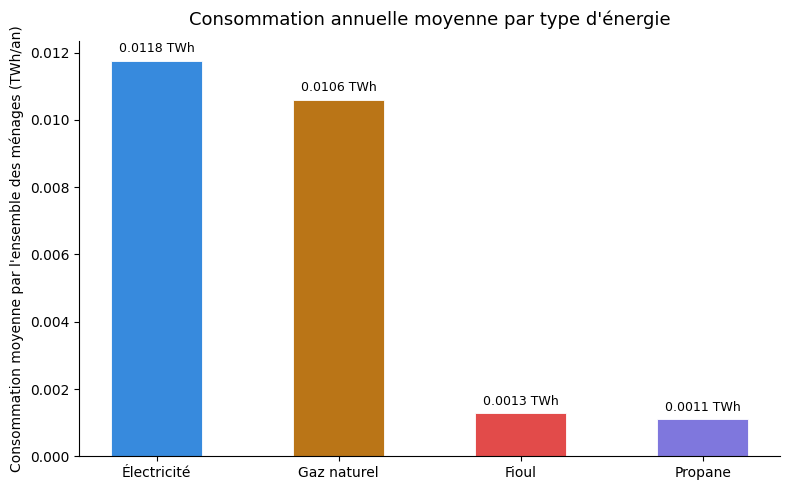

In [25]:
# consommation par énergie (élec / gaz / fioul / propane)(Barres empilées )

energy_cols = {
    "Électricité": existing([
        "out.electricity.heating.energy_consumption..kwh",
        "out.electricity.heating_fans_pumps.energy_consumption..kwh",
        "out.electricity.heating_hp_bkup.energy_consumption..kwh",
        "out.electricity.heating_hp_bkup_fa.energy_consumption..kwh",
        "out.electricity.cooling.energy_consumption..kwh",
        "out.electricity.cooling_fans_pumps.energy_consumption..kwh",
        "out.electricity.hot_water.energy_consumption..kwh",
        "out.electricity.hot_water_solar_th.energy_consumption..kwh",
        "out.electricity.clothes_washer.energy_consumption..kwh",
        "out.electricity.clothes_dryer.energy_consumption..kwh",
        "out.electricity.dishwasher.energy_consumption..kwh",
        "out.electricity.range_oven.energy_consumption..kwh",
        "out.electricity.refrigerator.energy_consumption..kwh",
        "out.electricity.freezer.energy_consumption..kwh",
        "out.electricity.television.energy_consumption..kwh",
        "out.electricity.plug_loads.energy_consumption..kwh",
        "out.electricity.ceiling_fan.energy_consumption..kwh",
        "out.electricity.pool_pump.energy_consumption..kwh",
        "out.electricity.pool_heater.energy_consumption..kwh",
        "out.electricity.permanent_spa_pump.energy_consumption..kwh",
        "out.electricity.permanent_spa_heat.energy_consumption..kwh",
        "out.electricity.lighting_interior.energy_consumption..kwh",
        "out.electricity.lighting_exterior.energy_consumption..kwh",
        "out.electricity.lighting_garage.energy_consumption..kwh",
        "out.electricity.ev_charging.energy_consumption..kwh",
        "out.electricity.mech_vent.energy_consumption..kwh",
        "out.electricity.well_pump.energy_consumption..kwh",
    ]),
    "Gaz naturel": existing([
        "out.natural_gas.heating.energy_consumption..kwh",
        "out.natural_gas.hot_water.energy_consumption..kwh",
        "out.natural_gas.clothes_dryer.energy_consumption..kwh",
        "out.natural_gas.range_oven.energy_consumption..kwh",
        "out.natural_gas.grill.energy_consumption..kwh",
        "out.natural_gas.pool_heater.energy_consumption..kwh",
        "out.natural_gas.permanent_spa_heat.energy_consumption..kwh",
        "out.natural_gas.lighting.energy_consumption..kwh",
        "out.natural_gas.fireplace.energy_consumption..kwh",
    ]),
    "Fioul": existing([
        "out.fuel_oil.heating.energy_consumption..kwh",
        "out.fuel_oil.hot_water.energy_consumption..kwh",
    ]),
    "Propane": existing([
        "out.propane.heating.energy_consumption..kwh",
        "out.propane.hot_water.energy_consumption..kwh",
        "out.propane.clothes_dryer.energy_consumption..kwh",
        "out.propane.range_oven.energy_consumption..kwh",
    ]),
}

energy_palette = {
    "Électricité": "#378ADD",
    "Gaz naturel": "#BA7517",
    "Fioul":       "#E24B4A",
    "Propane":     "#7F77DD",
}


energy_means = {
    label: df[cols].sum(axis=1).mean()
    for label, cols in energy_cols.items()
    if cols
}

fig3, ax3 = plt.subplots(figsize=(8, 5))
elabels = list(energy_means.keys())
evalues = [energy_means[l] / 1e6 for l in elabels]   # TWh / ménage
ecolors = [energy_palette[l] for l in elabels]

bars3 = ax3.bar(elabels, evalues, color=ecolors, width=0.5,
                edgecolor="white", linewidth=0.6)
ax3.bar_label(bars3, fmt="%.4f TWh", padding=4, fontsize=9)
ax3.set_ylabel("Consommation moyenne par l'ensemble des ménages (TWh/an)", fontsize=10)
ax3.set_title("Consommation annuelle moyenne par type d'énergie", fontsize=13, pad=12)
ax3.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz3_barres_energie.png", dpi=150)
plt.show()


C:\Users\yzouarhi\AppData\Local\Temp\ipykernel_21556\2898083781.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_stack.set_xticklabels(group_names, rotation=45, ha="right")


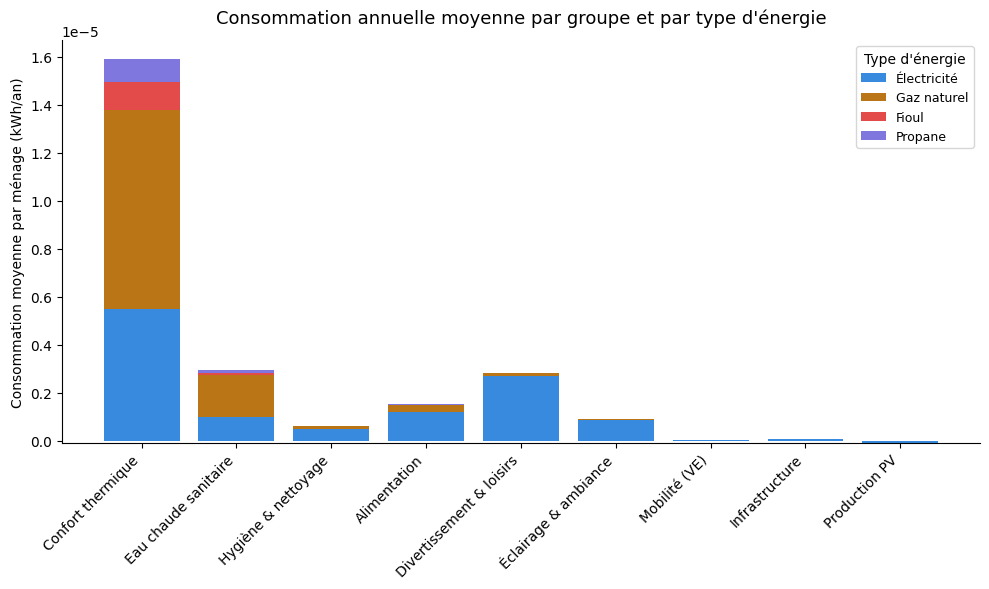

In [34]:
stack_data={}
for group_name, info in GROUPS.items():
    cols = info["cols"]
    if not cols:
        continue
    elec_cols=[ c for c in cols if c.startswith("out.electricity")and c.endswith("energy_consumption..kwh")]
    gas_cols=[ c for c in cols if c.startswith("out.natural_gas")and c.endswith("energy_consumption..kwh")]
    fuel_cols=[ c for c in cols if c.startswith("out.fuel_oil")and c.endswith("energy_consumption..kwh")]
    prop_cols=[ c for c in cols if c.startswith("out.propane")and c.endswith("energy_consumption..kwh")]
    stack_data[group_name] = {
        "Électricité": df[elec_cols].sum(axis=1)/1e9 if elec_cols else pd.Series(0, index=df.index),
        "Gaz naturel": df[gas_cols].sum(axis=1)/1e9 if gas_cols else pd.Series(0, index=df.index),
        "Fioul":       df[fuel_cols].sum(axis=1)/1e9 if fuel_cols else pd.Series(0, index=df.index),
        "Propane":     df[prop_cols].sum(axis=1)/1e9 if prop_cols else pd.Series(0, index=df.index),
    }
group_names = list(stack_data.keys())
elec_values = [stack_data[g]["Électricité"].mean() for g in group_names]
gas_values  = [stack_data[g]["Gaz naturel"].mean() for g in group_names]
fuel_values = [stack_data[g]["Fioul"].mean() for g in group_names]
prop_values = [stack_data[g]["Propane"].mean() for g in group_names]
fig_stack, ax_stack = plt.subplots(figsize=(10, 6))
b1=ax_stack.bar(group_names, elec_values, color=energy_palette["Électricité"], label="Électricité")
b2=ax_stack.bar(group_names, gas_values, bottom=elec_values, color=energy_palette["Gaz naturel"], label="Gaz naturel")
bottom_fuel = np.array(elec_values) + np.array(gas_values)
b3=ax_stack.bar(group_names, fuel_values, bottom=bottom_fuel, color=energy_palette["Fioul"], label="Fioul")
bottom_prop = bottom_fuel + np.array(fuel_values)
b4=ax_stack.bar(group_names, prop_values, bottom=bottom_prop, color=energy_palette["Propane"], label="Propane")
ax_stack.set_ylabel("Consommation moyenne par ménage (kWh/an)", fontsize=10)
ax_stack.set_title("Consommation annuelle moyenne par groupe et par type d'énergie", fontsize=13, pad=12)
ax_stack.set_xticklabels(group_names, rotation=45, ha="right")
ax_stack.legend(title="Type d'énergie", fontsize=9)
ax_stack.spines[["top", "right"]].set_visible(False)        
plt.tight_layout()
plt.savefig("viz4_barres_empilees.png", dpi=150)  
plt.show()

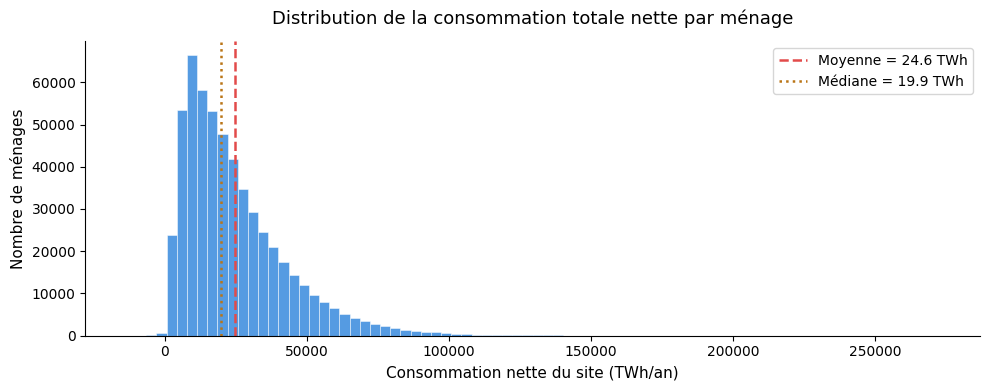

In [35]:
#Distribution (boxplot) de la consommation totale nette par ménage

if TOTAL_COL in df.columns:
    total_kwh = df[TOTAL_COL].dropna()#enlève les valeurs manquantes (NaN)

    fig4, ax4 = plt.subplots(figsize=(10, 4))
    ax4.hist(total_kwh , bins=80, color="#378ADD", edgecolor="white",
             linewidth=0.4, alpha=0.85)
    ax4.axvline(total_kwh.mean() , color="#E24B4A", lw=1.8,
                linestyle="--", label=f"Moyenne = {total_kwh.mean()/1e3:.1f} TWh")
    ax4.axvline(total_kwh.median() , color="#BA7517", lw=1.8,
                linestyle=":", label=f"Médiane = {total_kwh.median()/1e3:.1f} TWh")
    ax4.set_xlabel("Consommation nette du site (TWh/an)", fontsize=11)
    ax4.set_ylabel("Nombre de ménages", fontsize=11)
    ax4.set_title("Distribution de la consommation totale nette par ménage", fontsize=13, pad=12)
    ax4.legend(fontsize=10)
    ax4.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("viz4_distribution_totale.png", dpi=150)
    plt.show()

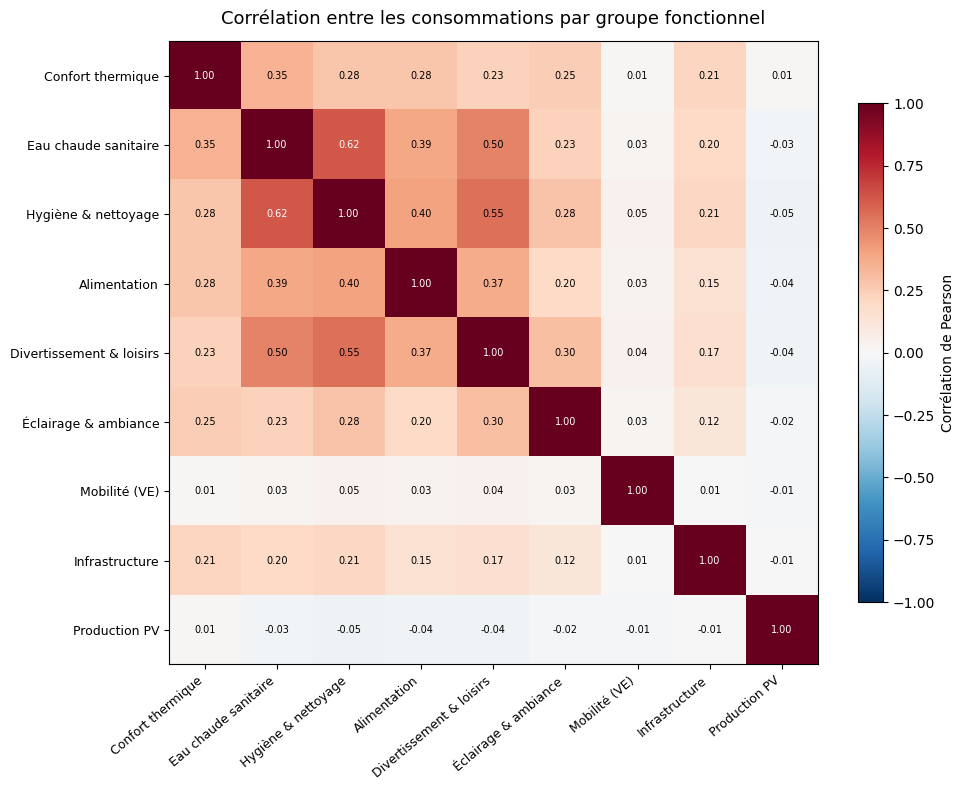

In [27]:
# Corrélation entre les consommations par groupe

group_df = pd.DataFrame({
    name: df[existing(info["cols"])].sum(axis=1)
    for name, info in GROUPS.items()
    if existing(info["cols"])
})

corr = group_df.corr()

fig5, ax5 = plt.subplots(figsize=(10, 8))
im = ax5.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax5.set_xticks(range(len(corr.columns)))
ax5.set_yticks(range(len(corr.index)))
ax5.set_xticklabels(corr.columns, rotation=40, ha="right", fontsize=9)
ax5.set_yticklabels(corr.index, fontsize=9)
plt.colorbar(im, ax=ax5, shrink=0.8, label="Corrélation de Pearson")

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        val = corr.values[i, j]
        ax5.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=7, color="white" if abs(val) > 0.6 else "black")

ax5.set_title("Corrélation entre les consommations par groupe fonctionnel", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("viz5_heatmap_correlation.png", dpi=150)
plt.show()

on eut observer une grand correlation entre "hygiène&nettoyage" et "eau chaude saitaire " ==> LOGIC

In [ ]:

# distribution du % du revenu dépensé en énergie

BURDEN_COL = "out.energy_burden..percentage"
if BURDEN_COL in df.columns:
    burden = df[BURDEN_COL].dropna()
    burden = burden[burden < 100]   # exclure valeurs aberrantes

    fig6, ax6 = plt.subplots(figsize=(10, 4))
    ax6.hist(burden, bins=60, color="#E85D24", edgecolor="white",
             linewidth=0.4, alpha=0.85)
    ax6.axvline(burden.mean(), color="#378ADD", lw=1.8, linestyle="--",
                label=f"Moyenne = {burden.mean():.1f}%")
    ax6.axvline(burden.median(), color="#1D9E75", lw=1.8, linestyle=":",
                label=f"Médiane = {burden.median():.1f}%")
    ax6.axvline(6, color="#E24B4A", lw=1.2, linestyle="-.",
                label="Seuil précarité = 6%")
    ax6.set_xlabel("Part du revenu consacrée à l'énergie (%)", fontsize=11)
    ax6.set_ylabel("Nombre de ménages", fontsize=11)
    ax6.set_title("Distribution de l'energy burden", fontsize=13, pad=12)
    ax6.legend(fontsize=10)
    ax6.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("viz6_energy_burden.png", dpi=150)
    plt.show()


In [ ]:
# Boxplots de la consommation par groupe (dispersion inter-ménages)

fig7, ax7 = plt.subplots(figsize=(13, 6))
box_data  = []
box_labels = []
box_colors = []

for name, info in GROUPS.items():
    cols = existing(info["cols"])
    if not cols:
        continue
    series = df[cols].sum(axis=1).dropna()
    series = series[series > 0]    # TWh, ménages non-zéro
    if len(series) < 10:
        continue
    box_data.append(series.values)
    box_labels.append(name)
    box_colors.append(info["color"])

bp = ax7.boxplot(
    box_data,
    patch_artist=True,
    notch=False,
    vert=True,
    showfliers=False,
    medianprops={"color": "white", "linewidth": 2},
    whiskerprops={"linewidth": 1},
    capprops={"linewidth": 1},
)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax7.set_xticks(range(1, len(box_labels) + 1))
ax7.set_xticklabels(box_labels, rotation=30, ha="right", fontsize=9)
ax7.set_ylabel("Consommation (TWh/an, ménages >0)", fontsize=10)
ax7.set_title("Dispersion de la consommation par groupe fonctionnel", fontsize=13, pad=12)
ax7.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("viz7_boxplots_groupes.png", dpi=150)
plt.show()

In [ ]:
#Confort non atteint (chauffage vs climatisation)

UH_HEAT = "out.unmet_hours.heating..hr"
UH_COOL = "out.unmet_hours.cooling..hr"

if UH_HEAT in df.columns and UH_COOL in df.columns:
    uh = df[[UH_HEAT, UH_COOL]].dropna()
    uh = uh[(uh[UH_HEAT] > 0) | (uh[UH_COOL] > 0)]

    fig8, axes8 = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    axes8[0].hist(uh[UH_HEAT], bins=50, color="#E85D24",
                  edgecolor="white", linewidth=0.4)
    axes8[0].set_title("Heures non confortables — Chauffage", fontsize=11)
    axes8[0].set_xlabel("Heures/an", fontsize=10)
    axes8[0].set_ylabel("Ménages", fontsize=10)
    axes8[0].spines[["top", "right"]].set_visible(False)

    axes8[1].hist(uh[UH_COOL], bins=50, color="#378ADD",
                  edgecolor="white", linewidth=0.4)
    axes8[1].set_title("Heures non confortables — Climatisation", fontsize=11)
    axes8[1].set_xlabel("Heures/an", fontsize=10)
    axes8[1].spines[["top", "right"]].set_visible(False)

    fig8.suptitle("Distribution des unmet hours (ménages avec inconfort uniquement)",
                  fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("viz8_unmet_hours.png", dpi=150)
    plt.show()

In [ ]:
# Consommation totale vs surface (sqft)

SQFT_COL = "in.sqft..ft2"
if TOTAL_COL in df.columns and SQFT_COL in df.columns:
    scatter_df = df[[TOTAL_COL, SQFT_COL]].dropna()
    scatter_df = scatter_df[
        (scatter_df[TOTAL_COL] > 0) &
        (scatter_df[SQFT_COL]  > 0)
    ]

    fig9, ax9 = plt.subplots(figsize=(9, 6))
    ax9.scatter(
        scatter_df[SQFT_COL],
        scatter_df[TOTAL_COL] / 1e3,
        alpha=0.15, s=6, color="#378ADD", rasterized=True
    )
    # droite de régression
    z = np.polyfit(scatter_df[SQFT_COL], scatter_df[TOTAL_COL] / 1e3, 1)
    p = np.poly1d(z)
    xline = np.linspace(scatter_df[SQFT_COL].min(),
                        scatter_df[SQFT_COL].max(), 200)
    ax9.plot(xline, p(xline), color="#E24B4A", lw=2, label="Régression linéaire")

    ax9.set_xlabel("Surface conditionnée (ft²)", fontsize=11)
    ax9.set_ylabel("Consommation nette (MWh/an)", fontsize=11)
    ax9.set_title("Consommation totale vs surface du logement", fontsize=13, pad=12)
    ax9.legend(fontsize=10)
    ax9.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("viz9_scatter_surface.png", dpi=150)
    plt.show()